## Setting UP external libraries and Database

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df=pd.read_csv("input_files/insurance.csv")

## Analysis

In [95]:
df.info()

# Inference :
# 1. There are 7 columns with 1337 entries 
# 2. The Dataset is complete and there is no need of imputation

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [96]:
df.columns = [x.upper() if x=="bmi" else x.title()  for x in df.columns]
df.columns

# Action:
# The column names are convertied to title casing

Index(['Age', 'Sex', 'BMI', 'Children', 'Smoker', 'Region', 'Charges'], dtype='str')

In [97]:
df["Children"].value_counts()

# Inference 
# People have 0 to 5 children

Children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [98]:
col_num = list(df.select_dtypes(include = ["number"]).columns)
col_num.remove("Charges")
col_cat = list(df.select_dtypes(include = ["object", "category", "str"]).columns)
col_label = ["Charges"]
print(f"Numerical Columns : {col_num}")
print(f"Categorical Columns : {col_cat}")
print(f"Label Columns : {col_label}")

Numerical Columns : ['Age', 'BMI', 'Children']
Categorical Columns : ['Sex', 'Smoker', 'Region']
Label Columns : ['Charges']


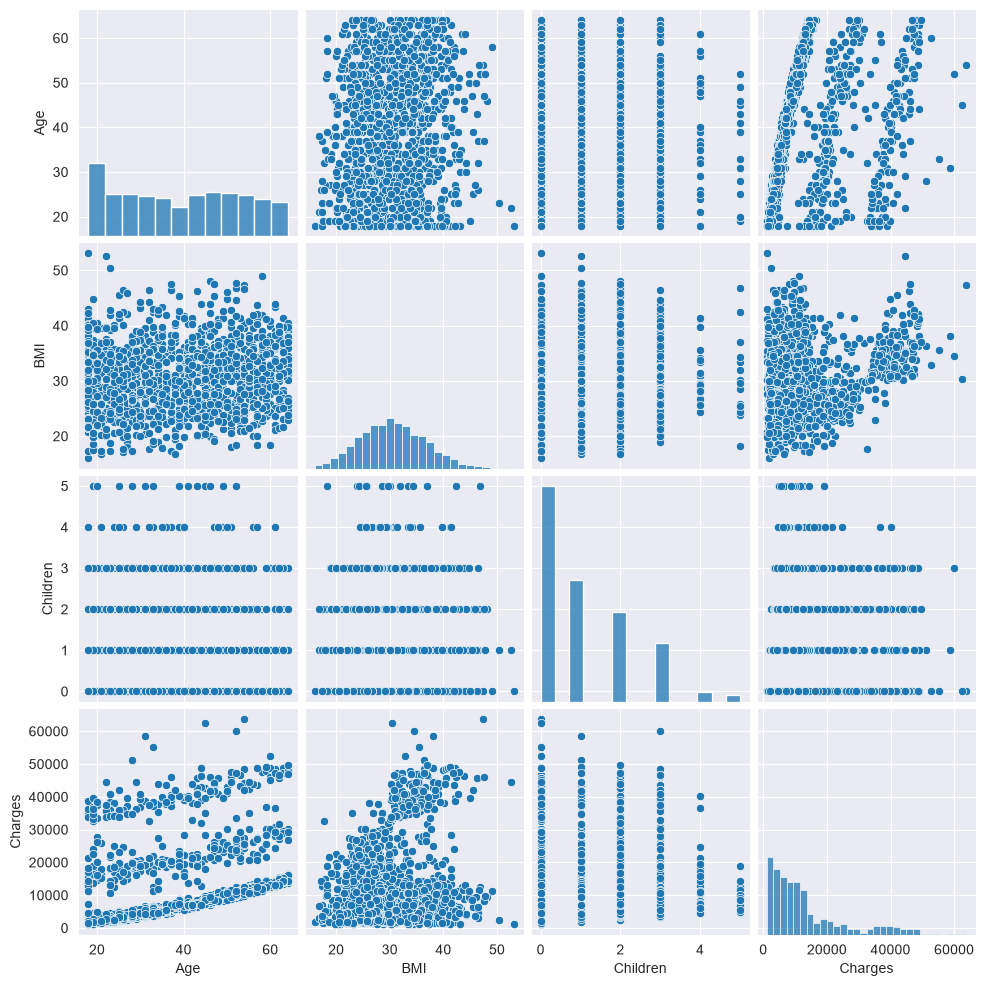

In [99]:
sns.pairplot(df)

# Inference 
# 1. BMI distribution follows a bell shaped curve
# 2. The charges vs Age graph shows that there is a hidden linear pattern
# 3. The charges vs BMI graph shows that some people regardless of the BMI have high charges

Text(0, 0.5, '')

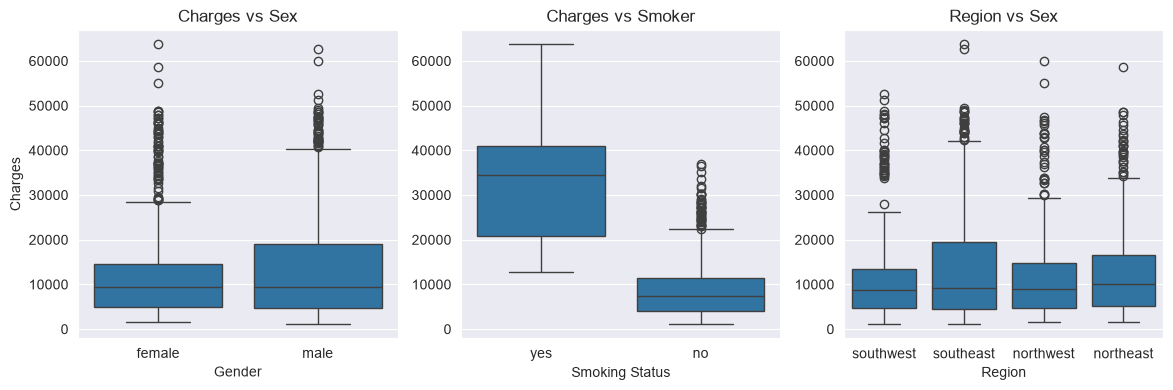

In [100]:
fig1, axs1 = plt.subplots(1,3, figsize=(14,4))

sns.boxplot(df, x="Sex", y="Charges", ax=axs1[0])
axs1[0].set_title("Charges vs Sex")
axs1[0].set_xlabel("Gender")

sns.boxplot(df, x="Smoker", y="Charges", ax=axs1[1])
axs1[1].set_title("Charges vs Smoker")
axs1[1].set_xlabel("Smoking Status")
axs1[1].set_ylabel("")

sns.boxplot(df, x="Region", y="Charges", ax=axs1[2])
axs1[2].set_title("Region vs Sex")
axs1[2].set_xlabel("Region")
axs1[2].set_ylabel("")

# Inference:
# There is not clear connection between Sex and Charges
# There is not clear connection between Region and Charges
# There is a cleat connection between Smoker and Charges

Text(0.5, 1.0, 'Charges vs Children (strat-sex)')

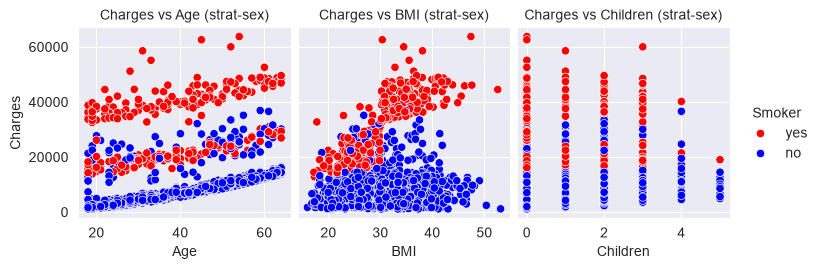

In [101]:
g = sns.pairplot(df, x_vars=["Age", "BMI", "Children"], y_vars=["Charges"], hue="Smoker", palette = ["red", "blue"])
g.axes[0,0].set_title("Charges vs Age (strat-sex)", fontsize = 10)
g.axes[0,1].set_title("Charges vs BMI (strat-sex)", fontsize = 10)
g.axes[0,2].set_title("Charges vs Children (strat-sex)", fontsize = 10)

# Inference:
# 1. Charges shows a clear linear relationship with Age but there is also a factor of Smoking status
# 2. Charges shows a linear relationship with Age but there is also a factor of Smoking status

<Axes: xlabel='Charges', ylabel='Density'>

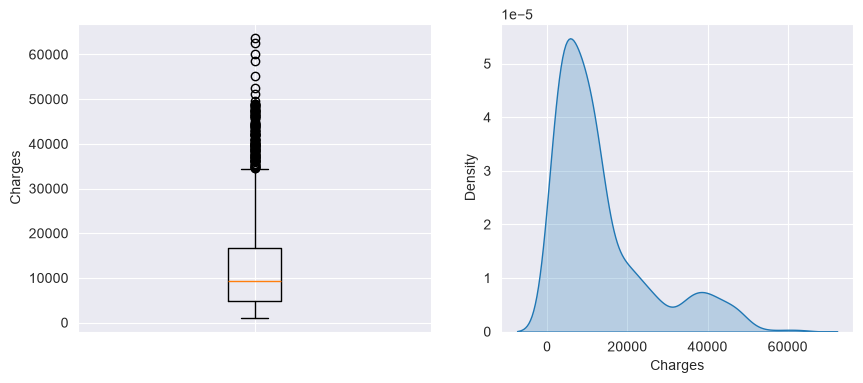

In [102]:
fig2, axs2 = plt.subplots(1,2, figsize=(10,4))
axs2[0].boxplot(df["Charges"])
axs2[0].set_xticks([1], labels = [""])
axs2[0].set_ylabel("Charges")
sns.kdeplot(df["Charges"], fill=True, ax=axs2[1])

# Inference:
# Labels has a right-tail

### Output graphs

In [103]:
# mkdir -p /kaggle/working/graphs

In [104]:
# fig1.savefig("output_files/Charges_vs_cat.png")
# g.savefig("output_files/Charges_vs_num_smoker.png")
# fig2.savefig("output_files/Charges_distribution.png")

## New useful columns

In [105]:
df["Age"].describe()

# Inference
# Maximum age = 64
# Minimum age = 18

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='count'>

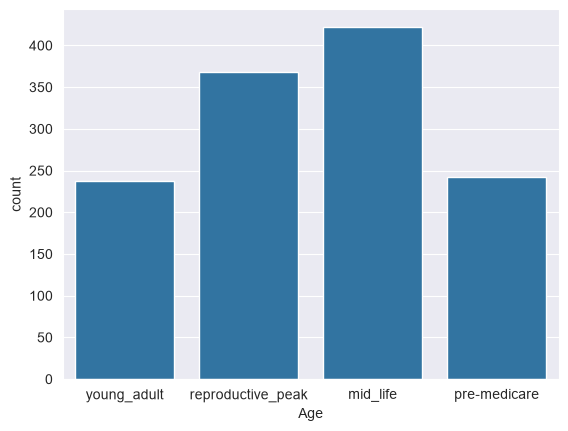

In [106]:
Age_Group = pd.Series(pd.cut(df["Age"],
                             bins = [18, 25, 39, 54, 64],
                             labels = ["young_adult", "reproductive_peak", "mid_life", "pre-medicare"]))
sns.barplot(Age_Group.value_counts())

In [107]:
Strat_col = pd.Series(map(str, Age_Group)) + "_" +pd.Series(map(str, df["Sex"]))
print(Strat_col)

0           young_adult_female
1                     nan_male
2       reproductive_peak_male
3       reproductive_peak_male
4       reproductive_peak_male
                 ...          
1333             mid_life_male
1334                nan_female
1335                nan_female
1336        young_adult_female
1337       pre-medicare_female
Length: 1338, dtype: str


## Stratification and label segregation

In [108]:
from sklearn.model_selection import train_test_split

data_training, data_testing = train_test_split(df, test_size=.2 , stratify = Strat_col, random_state=42)

# Action:
# Stratification done on the basis of age_group and gender

In [109]:
print(len(data_training[data_training["Sex"]=="female"])/len(data_training))
print(len(data_testing[data_testing["Sex"]=="female"])/len(data_testing))
print(len(df[df["Sex"]=="female"])/len(df))

# Inference:
# Stratification done successfully

0.49439252336448597
0.4962686567164179
0.4947683109118087


In [110]:
data_training_copy = data_training.copy()
label = pd.Series(data_training_copy["Charges"])

# Action:
# 1. A copy of training set is created
# 2. Label is separated

## Features Transformation

In [111]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer


pipeline_cat = make_pipeline(OneHotEncoder())
pipeline_num = make_pipeline(StandardScaler())

def smokers_fun(x):
    feature_series = x.iloc[:, 0]
    smokers_series = x.iloc[:, 1]
    return (feature_series*((smokers_series == "yes").astype(int))).to_frame()

def smokers_feature_name(function_transformer, feature_names_in):
    return [str(feature_names_in[0])+"_"+"of_smokers"]

pipeline_integrated_smoking = make_pipeline(FunctionTransformer(smokers_fun, feature_names_out=smokers_feature_name), StandardScaler())

def non_smokers_fun(x):
    feature_series = x.iloc[:, 0]
    non_smokers_series = x.iloc[:, 1]
    return (feature_series*((non_smokers_series == "no").astype(int))).to_frame()

def non_smokers_feature_name(function_transformer, feature_names_in):
    return [str(feature_names_in[0])+"_"+"of_non_smokers"]

pipeline_integrated_non_smoking = make_pipeline(FunctionTransformer(non_smokers_fun, feature_names_out=non_smokers_feature_name), StandardScaler())

# Actions:
# 1. Since charges depends linearly on BMI but the linear relation differs based on wheather the person is smoker or not, Smokers' BMI & non-smokers' BMI are teated as different dimensions.
# 2. For same reason Smokers' Age & non-smokers' Age are teated as different dimensions.

In [112]:
pipeline_num

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [113]:
pipeline_cat

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('onehotencoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, defa

In [114]:
pipeline_integrated_smoking

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('functiontransformer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function smo...001F4E7146AC0>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function smo...001F4E71449A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"kw_a

In [115]:
pipeline_integrated_non_smoking

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('functiontransformer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function non...001F4E7145DA0>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function non...001F4E7146980>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"kw_a

In [116]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("pipeline_num_default", pipeline_num, ["Children"]),
    ("pipeline_cat_default", pipeline_cat, ["Sex", "Region"]),
    ("BMI_smoking", pipeline_integrated_smoking, ["BMI", "Smoker"]),
    ("Age_smoking", pipeline_integrated_smoking, ["Age", "Smoker"]),
    ("BMI_non_smoking", pipeline_integrated_non_smoking, ["BMI", "Smoker"]),
    ("Age_non_smoking", pipeline_integrated_non_smoking, ["Age", "Smoker"])
])

# Actions:
# 1. Children column is subjected to default numerical pipeline
# 1. Sex and Region columnn are subjected to default categorical pipeline
# 1. BMI and Age columns are subjected to smokers and non-smokers pipeline


In [117]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline_num_default', ...), ('pipeline_cat_default', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``

## Engaging Model

In [118]:
from sklearn.linear_model import LinearRegression

linear_model = make_pipeline(preprocessing, LinearRegression())

In [119]:
linear_model.fit(data_training_copy, label)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','Sex','BMI',...,'Smoker','Region','Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline_num_default', ...), ('pipeline_cat_default', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

### Output model

In [120]:
# import joblib
# joblib.dump(linear_model, "output_files/linear_model.pkl")

## Test on Training set and Cross-Validation

In [121]:
predictions_training = linear_model.predict(data_training_copy)
print(predictions_training[:5].round(2))
print(label[:5].round(2).to_list())

[ 1699.14 32732.51  8014.12 39887.84  2799.16]
[1639.56, 36085.22, 7133.9, 42969.85, 1977.82]


In [122]:
from sklearn.metrics import root_mean_squared_error
rmse_training = root_mean_squared_error(label, predictions_training)
print(f"rmse_training = {rmse_training}")

rmse_training = 5027.7457020444435


In [123]:
from sklearn.model_selection import cross_val_score

rmse_train_10folds = -cross_val_score(linear_model, data_training_copy, label, scoring="neg_root_mean_squared_error", cv=10)
print(f"10-folds cross validation rmse :\n{pd.Series(rmse_train_10folds).describe()}")

10-folds cross validation rmse :
count      10.000000
mean     5054.064360
std       554.350719
min      3874.950147
25%      4916.079897
50%      5144.461468
75%      5325.552332
max      5957.641458
dtype: float64


## Predictions on Test set

In [124]:
predictions_testing = linear_model.predict(data_testing)
print(predictions_testing[:5].round(2))
print(data_testing["Charges"][:5].round(2).to_list())

[15014.21 40557.68 13657.17 36749.46  3849.38]
[12574.05, 40932.43, 13224.69, 39836.52, 2902.91]


In [125]:
from sklearn.metrics import mean_absolute_error, r2_score

rmse_testing = root_mean_squared_error(data_testing["Charges"], predictions_testing)
mae_testing = mean_absolute_error(data_testing["Charges"], predictions_testing)
r2_testing = r2_score(data_testing["Charges"], predictions_testing)

print(f"rmse_testing = {rmse_testing}")
print(f"mae_testing = {mae_testing}")
print(f"mae_testing/median_charges = { (mae_testing/np.median(data_testing["Charges"])*100).round(2) }%")
print(f"r2_testing = {r2_testing}")

rmse_testing = 5159.8934596198105
mae_testing = 3109.3370547766826
mae_testing/median_charges = 32.75%
r2_testing = 0.8388877802188905


### Output predictions

In [126]:
# output = data_testing.copy()
# output["Predicted_Charges"] = predictions_testing
# output["Residual"] = output["Charges"] - output["Predicted_Charges"]
#
# output.to_csv("output_files/insurance_predictions.csv", index=False)